# Avaliação e Comparação dos Métodos de Busca Semântica

Este notebook avalia e compara os quatro métodos de busca implementados no sistema, sob a ótica que interessa à disciplina: **complexidade, desempenho e trade-offs**.

## O problema

O sistema recebe uma pergunta em linguagem natural (*"um hacker descobre que a realidade é uma simulação"*) e precisa recuperar, entre **42.204 sinopses** do CMU Movie Summary Corpus, aquelas semanticamente mais próximas. Há duas decisões **independentes**:

1. **Como transformar texto em vetor** (representação): TF-IDF, Word2Vec (média) ou Sentence Embeddings (MiniLM).
2. **Como encontrar os vizinhos mais próximos** (algoritmo de busca): varredura linear exata `O(N)` ou grafo HNSW aproximado (`~O(log N)`).

Combinando essas decisões, avaliamos quatro métodos:

| Método | Representação | Busca |
|---|---|---|
| TF-IDF (linear) | contagem de palavras (esparso) | linear exata |
| Word2Vec (linear) | média de vetores de palavras (100d) | linear exata |
| Sentence Emb. (linear) | MiniLM (384d) | linear exata |
| Sentence Emb. (HNSW) | MiniLM (384d) | HNSW aproximada |

Comparar métodos que só diferem na **representação** (mesma busca linear) isola o efeito da representação; comparar *Sentence Emb. linear* vs *HNSW* (mesma representação) isola o efeito do **algoritmo de busca** — o trade-off velocidade × precisão que é o coração deste trabalho.

## Roteiro do notebook

1. **Metodologia** — gabarito, categorias e métricas.
2. **Fase 1 — Construção (offline):** quanto custa treinar/indexar cada método (o *primeiro* passo do pipeline).
3. **Fase 2 — Busca (online):** tempo por query e qualidade (hit@k, recall@k, MRR).
4. **Visão consolidada** dos três eixos.
5. **Complexidade** e **trade-offs**.
6. **Queries de usuário** e **conclusão**.

In [1]:
import os, sys

# Sobe até a raiz do projeto (pasta que contém data/ e evaluation/), para que os
# imports e os caminhos relativos "data/..." usados pelos buscadores funcionem,
# independentemente de onde o Jupyter foi iniciado.
root = os.getcwd()
while not (os.path.isdir(os.path.join(root, "data")) and os.path.isdir(os.path.join(root, "evaluation"))):
    parent = os.path.dirname(root)
    if parent == root:
        raise RuntimeError("Raiz do projeto nao encontrada — rode o Jupyter dentro do repositorio.")
    root = parent
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)

import pandas as pd
import matplotlib.pyplot as plt

from evaluation.queries import ALL_QUERIES
from evaluation.build_times import measure_build_times
from evaluation.benchmark import (
    build_searchers, collect_raw, aggregate, aggregate_by_category, K_VALUES,
)

## Metodologia de avaliação

### Gabarito (queries de avaliação)

Avaliar qualidade exige saber a resposta certa. Montamos **55 queries** em linguagem natural, cada uma com o(s) filme(s) esperado(s) como gabarito, todos verificados contra o dataset. Elas são divididas em **quatro categorias**, o que permite analisar viés:

- **`iconic` (20)** — blockbusters de enredo muito distintivo, parafraseados por nós. Caso fácil / limite superior.
- **`obscure` (15)** — filmes cult/menos populares, com a query redigida a partir da **sinopse real**. Estressam os métodos.
- **`multi` (4)** — queries de recomendação (franquias), com **vários** filmes relevantes. É a única categoria em que `recall@k` difere de `hit@k`.
- **`user` (16)** — descrições curtas e vagas escritas *"como um usuário pediria"*. Medem a utilidade no uso real e reduzem o viés de autoria.

### Métricas

- **hit@k** — a query "acerta" se **pelo menos um** filme relevante aparece entre os `k` primeiros resultados (binário, média sobre as queries).
- **recall@k** — **fração** dos filmes relevantes recuperados no top-k. Com um único relevante (iconic/obscure/user) **coincide com hit@k**; só é informativo no `multi`.
- **MRR** (*Mean Reciprocal Rank*) — média de `1/posição` do primeiro acerto. Diferencia "acertou em 1º" (1.0) de "acertou em 5º" (0.2).

### Cronometragem

Todos os tempos usam `perf_counter`. Na busca (Fase 2), há **warm-up** e mantém-se o **menor** de 5 execuções por query (reduz ruído de GC/escalonador). Os tempos são **específicos desta máquina** — o que importa é a **razão** entre métodos, não o valor absoluto.

## Fase 1 — Construção: treino e indexação

Este é o **primeiro passo do pipeline**: antes de qualquer busca, cada método precisa construir sua estrutura a partir das sinopses limpas. É um custo pago **uma única vez**:

- **TF-IDF** — ajusta (*fit*) a matriz TF-IDF sobre o corpus.
- **Word2Vec** — treina o modelo do zero e gera o vetor-médio de cada filme.
- **Sentence Embeddings** — roda o MiniLM sobre as 42k sinopses (etapa **compartilhada** pelos métodos denso-linear e HNSW).
- **HNSW** — constrói o índice FAISS sobre os embeddings já gerados.

> A célula abaixo **remede tudo do zero** (treina o Word2Vec, gera os 42k embeddings, constrói o índice). Pode levar **1 a 2 minutos**.

In [2]:
build_per_method, build_detail = measure_build_times()

Documentos: 42204

TF-IDF...
  fit_transform: 4.34s
Word2Vec...
  treino: 19.12s
  vetores-medio: 10.90s
Sentence Embeddings (MiniLM)... (pode levar alguns minutos)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  encode dos documentos: 73.13s
HNSW (FAISS)...
  build do indice: 1.71s


In [3]:
# Tempo de construção por método (sequência: TF-IDF, Word2Vec, Sentence linear, HNSW)
pd.DataFrame({"Construcao (s)": build_per_method}).round(1)

,Construcao (s)
TF-IDF (linear),4.3
Word2Vec (linear),30.0
Sentence Emb. (linear),73.1
Sentence Emb. (HNSW),74.8


### Leitura

- **A geração dos embeddings do MiniLM domina o custo offline** — é rodar uma rede neural 42 mil vezes. TF-IDF e Word2Vec constroem em segundos, mas (veremos) entregam qualidade muito menor.
- **Construir o índice HNSW custa apenas alguns segundos** sobre os embeddings já prontos. Esse custo minúsculo se paga com folga na Fase 2, onde cada busca fica bem mais rápida.
- Ou seja, já aqui aparece o padrão central: *qualidade* e *velocidade de busca* têm preços diferentes, pagos em fases diferentes.

## Fase 2 — Busca: tempo e qualidade

Com as estruturas construídas, medimos o que o usuário paga **a cada pergunta**: o tempo de busca por query e a qualidade dos resultados. A célula abaixo carrega o MiniLM e os índices e roda os quatro métodos sobre as 55 queries (5 repetições cada). Guardamos os **dados crus** (ids recuperados + tempos) e derivamos todas as métricas a partir deles.

In [4]:
searchers = build_searchers()
raw = collect_raw(searchers)

overall = pd.DataFrame(aggregate(raw)).set_index("method")
by_cat = pd.DataFrame(aggregate_by_category(raw))
print("Coleta concluida.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Coleta concluida.


### Resultado geral (qualidade × velocidade)

`search_ms` é o tempo médio de busca por query; `hit@k` cresce com `k` (mais chances de o filme certo estar entre os `k` primeiros).

In [5]:
cols = ["search_ms"] + [f"hit@{k}" for k in K_VALUES] + ["mrr"]
overall[cols].round(3)

,search_ms,hit@1,hit@3,hit@5,hit@10,mrr
method,,,,,,
TF-IDF (linear),50.584,0.091,0.109,0.164,0.200,0.117
Word2Vec (linear),9.114,0.000,0.000,0.000,0.000,0.000
Sentence Emb. (linear),46.408,0.182,0.255,0.345,0.418,0.248
Sentence Emb. (HNSW),6.386,0.182,0.218,0.273,0.327,0.220


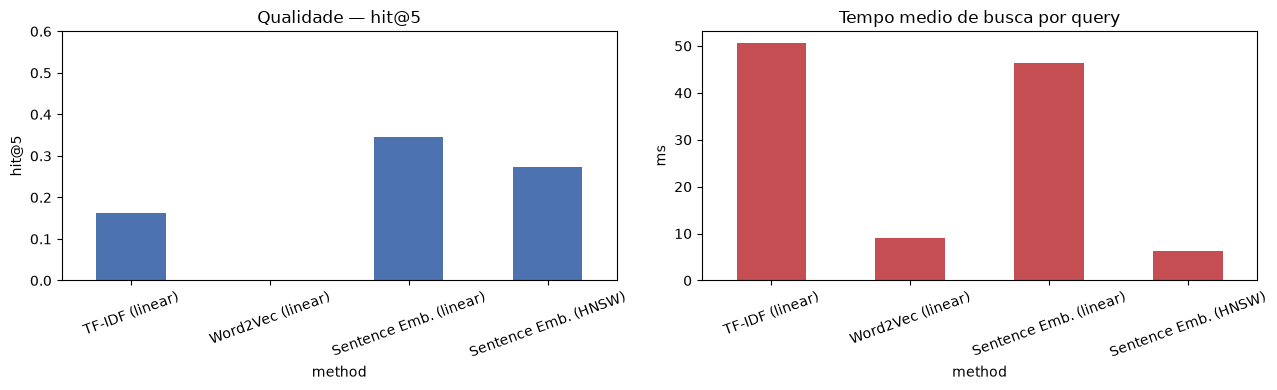

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

overall["hit@5"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Qualidade — hit@5")
axes[0].set_ylabel("hit@5")
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis="x", rotation=20)

overall["search_ms"].plot.bar(ax=axes[1], color="#C44E52")
axes[1].set_title("Tempo medio de busca por query")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Leitura

- **TF-IDF** — busca por *palavra exata*. Como as queries parafraseiam o enredo (pouco vocabulário em comum), acerta pouco. É o baseline não-semântico.
- **Word2Vec (média)** — treinado só nas 42k sinopses, com vocabulário ruidoso (`min_count=1`); a média de vetores dilui o significado e o resultado é fraquíssimo.
- **Sentence Embeddings (MiniLM)** — melhor qualidade em todas as métricas: a rede lê a frase inteira e captura significado ("carro" ≈ "automóvel").
- **HNSW** — usa os *mesmos* vetores do MiniLM, mas busca aproximada: qualidade levemente menor que a linear, em troca de tempo de busca muito menor.

### Qualidade por categoria (análise de viés)

Separando por categoria, vemos **onde** cada método brilha ou falha — não só a média global.

In [7]:
order = ["iconic", "obscure", "multi", "user"]
pivot = by_cat.pivot(index="method", columns="category", values="hit@5")
pivot = pivot[[c for c in order if c in pivot.columns]]
pivot.round(2)

category,iconic,obscure,multi,user
method,,,,
Sentence Emb. (HNSW),0.30,0.27,0.75,0.12
Sentence Emb. (linear),0.35,0.47,0.75,0.12
TF-IDF (linear),0.05,0.40,0.50,0.00
Word2Vec (linear),0.00,0.00,0.00,0.00


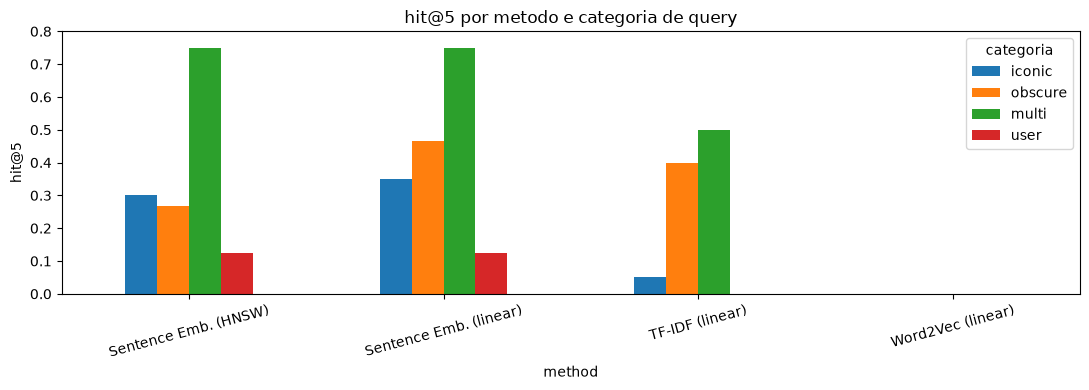

In [8]:
ax = pivot.plot.bar(figsize=(11, 4))
ax.set_title("hit@5 por metodo e categoria de query")
ax.set_ylabel("hit@5")
ax.set_ylim(0, 0.8)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="categoria")
plt.tight_layout()
plt.show()

#### `recall@k` e o `multi`

`recall@k` só difere de `hit@k` quando há vários relevantes. Abaixo, hit e recall são idênticos em `iconic`/`obscure`/`user` (um relevante só) e divergem apenas em `multi` — onde o método acha *pelo menos um* filme da franquia (hit alto) mas não a franquia inteira (recall menor).

In [9]:
by_cat[by_cat["category"] == "multi"][["method", "hit@5", "recall@5", "mrr"]].round(3).reset_index(drop=True)

,method,hit@5,recall@5,mrr
0,TF-IDF (linear),0.50,0.188,0.300
1,Word2Vec (linear),0.00,0.000,0.000
2,Sentence Emb. (linear),0.75,0.292,0.438
3,Sentence Emb. (HNSW),0.75,0.292,0.438


## Visão consolidada — os três eixos

Juntando as duas fases numa tabela só, comparamos os quatro métodos nos três eixos avaliados: **construção** (Fase 1), **tempo de busca** (Fase 2) e **qualidade**.

In [10]:
final = overall[["search_ms", "hit@5", "mrr"]].copy()
final["build_s"] = pd.Series(build_per_method)
final = final[["build_s", "search_ms", "hit@5", "mrr"]]
final.columns = ["Construcao (s)", "Busca (ms)", "hit@5", "MRR"]
final.round({"Construcao (s)": 1, "Busca (ms)": 1, "hit@5": 2, "MRR": 3})

,Construcao (s),Busca (ms),hit@5,MRR
method,,,,
TF-IDF (linear),4.3,50.6,0.16,0.117
Word2Vec (linear),30.0,9.1,0.00,0.000
Sentence Emb. (linear),73.1,46.4,0.35,0.248
Sentence Emb. (HNSW),74.8,6.4,0.27,0.220


### O que a tabela consolidada revela

- **Construir o índice HNSW custa pouquíssimo** sobre os embeddings já prontos (~2 s), mas torna cada busca **~11x mais rápida** — o melhor negócio da tabela.
- **O custo offline é dominado pelos embeddings**, não pela indexação: pagar por qualidade (MiniLM) é caro; acelerar a busca (HNSW) é barato.
- Somando os três eixos, **MiniLM + HNSW** é o melhor equilíbrio geral: qualidade próxima da busca exata densa, o menor tempo de busca, e custo de construção quase idêntico ao da versão linear.

## Análise de complexidade

Notação: **N** = nº de documentos (42.204), **V** = vocabulário, **d** = dimensão do vetor, **L** = comprimento médio de um documento (tokens), **Q** = comprimento da query.

### Fase construção — uma vez

| Etapa | Tempo | Espaço | Observação |
|---|---|---|---|
| TF-IDF (fit) | `O(N·L)` | `O(nnz)` esparso | varre todos os tokens; matriz `N×V` quase toda zero |
| Word2Vec (treino) | `O(E · N·L · d)` | `O(V·d)` | `E` = épocas; janela deslizante sobre o corpus |
| Embeddings MiniLM | `O(N · C_fwd)` | `O(N·d)` | `C_fwd` = custo de um *forward* do Transformer (constante grande) |
| Índice HNSW (build) | `O(N · log N · d)` | `O(N·(d + M))` | cada inserção faz uma busca + conecta a `M` vizinhos |

A geração dos embeddings domina o tempo offline — o que os números da Fase 1 confirmam.

### Fase busca — por query

**1. Vetorização da query:** TF-IDF `O(Q)`; Word2Vec `O(Q·d)`; MiniLM `O(C_fwd)` (um *forward*).

**2. Busca dos k vizinhos:**

| Método | Complexidade | Cresce com N? |
|---|---|---|
| Linear (TF-IDF / W2V / Sentence) | `O(N·d)` + `O(N log k)` para o top-k | **Sim, linearmente** |
| HNSW | `~O(log N · d)` | **Sublinear** |

**Este é o ponto central do trabalho.** A busca linear compara a query com **todos** os `N` vetores — cresce com o acervo. O HNSW navega um grafo hierárquico e só examina uma vizinhança `~O(log N)`, sem visitar a maioria dos vetores — por isso escala. O preço é ser **aproximado**: pode não achar o verdadeiro vizinho mais próximo (a linear acha sempre). Trocamos **exatidão** por **tempo sublinear**.

## Trade-offs

**Velocidade × qualidade (representação).** A qualidade segue MiniLM `≫` TF-IDF `≫` Word2Vec, mas o MiniLM é o mais caro para *vetorizar* a query (um *forward* de rede, dezenas de ms) — TF-IDF/Word2Vec vetorizam em microssegundos. O método mais forte é também o mais caro por consulta.

**Exato × aproximado (algoritmo de busca).** Com os *mesmos* vetores MiniLM: a linear entrega a qualidade máxima daquela representação em `O(N·d)`; o HNSW entrega `~O(log N·d)` perdendo pouca qualidade — perda **maior nos filmes obscuros** (regiões mais densas/ambíguas, onde a aproximação erra mais). O HNSW compensa em acervos grandes, onde a linear se torna inviável.

O gráfico posiciona os quatro métodos nesse plano (**canto superior-esquerdo = rápido e bom**).

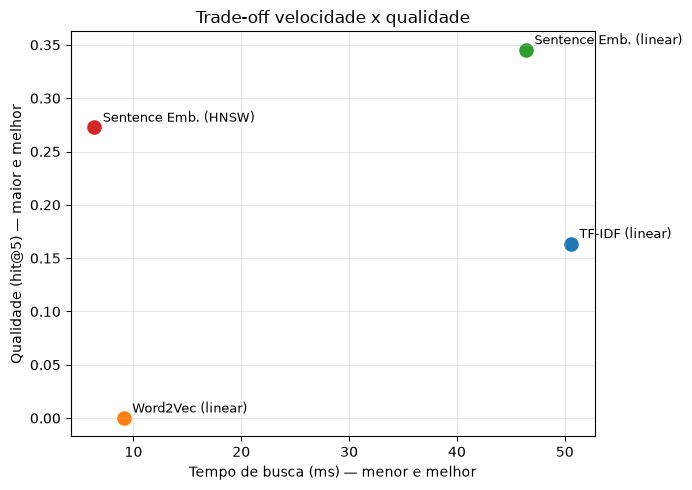

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for method, r in overall.iterrows():
    ax.scatter(r["search_ms"], r["hit@5"], s=90)
    ax.annotate(method, (r["search_ms"], r["hit@5"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Tempo de busca (ms) — menor e melhor")
ax.set_ylabel("Qualidade (hit@5) — maior e melhor")
ax.set_title("Trade-off velocidade x qualidade")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Queries de usuário — o teste de realidade

A categoria `user` é a mais honesta sobre a utilidade prática: descrições curtas, vagas e imperfeitas, como um usuário real digitaria (*"um panda aprende kung fu"*). O padrão é revelador:

- Com **TF-IDF** e **Word2Vec**, o hit@5 das queries de usuário é **0** — métodos fracos não lidam com entradas vagas.
- Com **Sentence Embeddings**, sobe para **~0.12** — a semântica do MiniLM começa a "entender" a intenção mesmo sem vocabulário compartilhado.

Ou seja: **a utilidade para o usuário real cresce à medida que a semântica melhora**. Mas com honestidade — `hit@5 = 0.12` é o filme certo no top-5 em ~1 a cada 8 buscas; contra as queries bem elaboradas (iconic `0.35`, obscure `0.47`), as de usuário ficam **bem abaixo**. O app **ganha alguma utilidade real, mas ainda longe de boa** — esperado dados os recursos (modelo pequeno, pré-processamento simples, sinopses longas vs queries curtas).

In [12]:
# Evidência: hit@5 das queries de usuário sobe com a força semântica do método
by_cat[by_cat["category"] == "user"][["method", "hit@5", "mrr"]].round(3).reset_index(drop=True)

,method,hit@5,mrr
0,TF-IDF (linear),0.000,0.000
1,Word2Vec (linear),0.000,0.000
2,Sentence Emb. (linear),0.125,0.131
3,Sentence Emb. (HNSW),0.125,0.131


## Conclusão

- **A representação importa mais que o algoritmo de busca para a qualidade.** MiniLM domina; TF-IDF e Word2Vec ficam muito atrás. O *como vetorizar* define o teto de qualidade.
- **O algoritmo de busca importa para a escala, não para a qualidade.** O HNSW entrega busca sublinear com perda pequena de qualidade — irrelevante em 42k filmes, decisivo em milhões.
- **Melhor qualidade custa mais** (offline nos embeddings, online no *forward* por query), mas o HNSW recupera o custo de busca com uma indexação baratíssima. **MiniLM + HNSW** é o melhor equilíbrio geral.
- **Sob a ótica do usuário real, o sistema é modestamente útil**; queries vagas melhoram com a semântica, mas há muito espaço — modelos maiores, melhor pré-processamento e reranqueamento seriam os próximos passos.

Em complexidade, o projeto ilustra bem o trade-off que a disciplina estuda: **exato `O(N)` × aproximado `O(log N)`**, e como uma escolha estrutural (um grafo hierárquico de navegação) transforma o custo assintótico da operação mais frequente do sistema.